In [49]:
import matplotlib.pyplot as plt
import pandas as pd
from glob import glob
import numpy as np
import seaborn as sns

In [129]:
cases=sorted(glob("/home/*/SAAB-Experiment/exp8/*/*/output_case*.csv"))
confidence_cases=sorted((glob("/home/*/SAAB-Experiment/exp8/*/*/confidence_case_*.csv")))
imus=sorted((glob("/home/*/SAAB-Experiment/exp8/*/*/output_IMU_case_*.csv")))

In [133]:
cases=sorted(glob("/home/*/SAAB-Experiment/exp7/*/*/output_case*.csv"))
confidence_cases=sorted((glob("/home/*/SAAB-Experiment/exp7/*/*/confidence_case_*.csv")))
imus=sorted((glob("/home/*/SAAB-Experiment/exp7/*/*/output_IMU_case_*.csv")))

In [134]:
imus

['/home/saab/SAAB-Experiment/exp7/data/not_straight_wall_3_2025_07_07_12_59_25.bag/output_IMU_case_not_straight_wall_3_2025_07_07_12_59_25.bag.csv',
 '/home/saab/SAAB-Experiment/exp7/data/not_straight_wall_3_IMU_only_2025_07_07_13_09_14.bag/output_IMU_case_not_straight_wall_3_IMU_only_2025_07_07_13_09_14.bag.csv']

In [135]:
ed_1=[]
ed_2=[]
ed_3=[]
for case in confidence_cases[:]:
    df=pd.read_csv(case)
    print(case.split("/")[-1])
    expected_diff_1=np.abs(np.mean(np.diff(df["Sonar_distance_1"]))/len(df))
    expected_diff_2=np.abs(np.mean(np.diff(df["Sonar_distance_2"]))/len(df))
    expected_diff_3=np.abs(np.mean(np.diff(df["Sonar_distance_3"]))/len(df))
    ed_1.append(expected_diff_1)
    ed_2.append(expected_diff_2)
    ed_3.append(expected_diff_3)
    print("X",expected_diff_1,"Y:",expected_diff_2,"Z:",expected_diff_3)

confidence_case_not_straight_wall_3_2025_07_07_12_59_25.bag.csv
X 0.0037933372891413067 Y: 0.0034419061343279366 Z: 0.0


In [136]:
print(np.mean(ed_1))
print(np.mean(ed_2))
print(np.mean(ed_3))

0.0037933372891413067
0.0034419061343279366
0.0


-0.013428456170789074


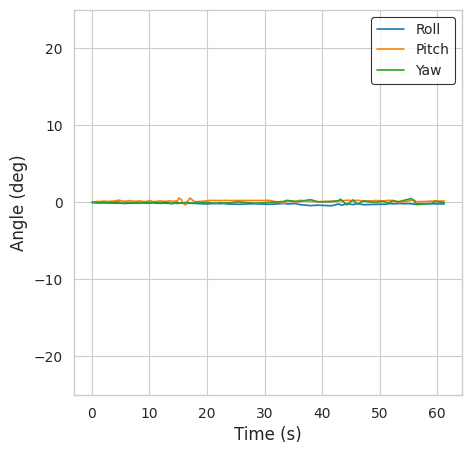

In [137]:
i=0
plt.figure(figsize=(5,5))
for case in cases[:]:
    try:
    
        df=pd.read_csv(case)
        #plt.title("Angles")
        plt.plot(df["Timestamp"]-df["Timestamp"][0],df["Angle_X"]-df["Angle_X"][0],label="Roll")
        #plt.figure()
        plt.plot(df["Timestamp"]-df["Timestamp"][0],df["Angle_Y"]-df["Angle_Y"][0],label="Pitch")
        
        #plt.figure()
        plt.plot(df["Timestamp"]-df["Timestamp"][0],df["Angle_Z"]-df["Angle_Z"][0],label="Yaw")
        ls=np.ones_like(df["Angle_Z"])
        #plt.plot(np.mean(-df["Angle_Z"])*ls)
        print(np.mean(-df["Angle_Z"]))
        #plt.xlim(0,2)
        plt.ylim(-25,25)
        plt.xlabel('Time (s)')
        plt.ylabel("Angle (deg)")
        plt.grid(True)
        plt.legend()
        i+=1
    except:
        print("No angles")

In [138]:
import matplotlib.patches as patches
def plot_ellipses(ax, df,s1="Sonar_distance_2",s2="Sonar_distance_1",c1="Confidence_2",c2="Confidence_1",scale=5,rezero=False):
    for idx, row in df.iterrows():
        # Confidence for color intensity, using the average of x and y confidence
        #print(row)
        width = scale*(1-(row[c1]) / 100)
        height =scale*(1-(row[c2]) / 100)
        #print(width)
        #print(height)
        if(rezero==False):
        # Draw ellipse to represent confidence in x and y
            ellipse = patches.Ellipse(((row[s1])/1000, (row[s2]/1000)), width, height,
                                  color=(0, 1, 0, 0.25), fill=True)
        else:
            ellipse = patches.Ellipse(((row[s1]-df[s1].iloc[0])/1000, (row[s2]-df[s2].iloc[0])/1000), width, height,
                                color=(0, 1, 0, 0.25), fill=True)
        ax.add_patch(ellipse)

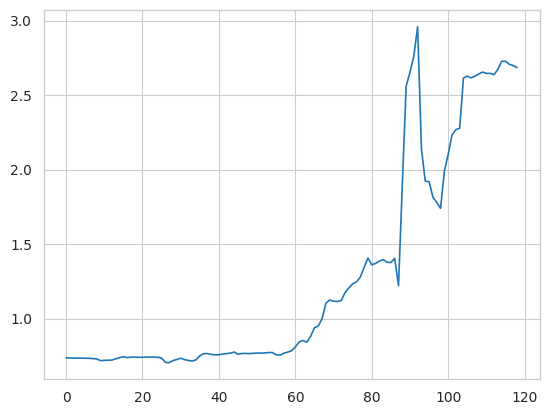

In [141]:
df_main=pd.read_csv(cases[0])
plt.plot(df_main["Pose_Y"],label="KF",color="tab:blue")

In [142]:
origin_x=df_main["Pose_X"][0]
origin_y=df_main["Pose_Y"][0]
gt=2

In [143]:
cumulative_displacement_x=np.linspace(origin_x,gt+origin_x,1000)
cumulative_displacement_y=np.linspace(origin_y,gt+origin_y,1000)
cumulative_displacement_z=np.linspace(0,0,1000)

/home/saab/SAAB-Experiment/exp7/data/not_straight_wall_3_2025_07_07_12_59_25.bag/output_IMU_case_not_straight_wall_3_2025_07_07_12_59_25.bag.csv
0       0.730000
1       0.730000
2       0.730000
3       0.739159
4       0.742180
          ...   
2684    2.686283
2685    2.686281
2686    2.686280
2687    2.686248
2688    2.686247
Name: Pose_Y, Length: 2689, dtype: float64
KF error _X 0.38200998332499647
KF_x_SD 0.6699829488314268
KF error _Y 0.3030729165417309
KF_y_SD 0.7167825681172725
KF error _Z 0.00018765977678006956
KF_z_SD 0.00017639174450274523
IMU error _X (MAE): 0.20221747757160408
IMU error _Y (MAE): 0.39740535392842086
IMU error _Z (MAE): 6.428027612011958e-05
2689
/home/saab/SAAB-Experiment/exp7/data/not_straight_wall_3_IMU_only_2025_07_07_13_09_14.bag/output_IMU_case_not_straight_wall_3_IMU_only_2025_07_07_13_09_14.bag.csv
IMU error _X 16.235940550419137
IMU_x_SD 13.642927728701466
IMU error _Y 22.811711073769374
IMU_y_SD 18.343604853115217
IMU error _Z 0.23217400595343782

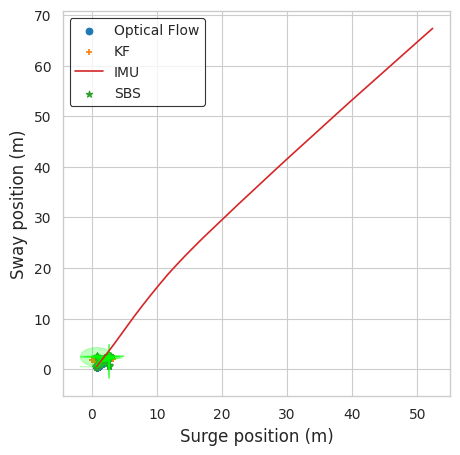

In [144]:
i=0
fig, ax = plt.subplots(1,1,figsize=(5, 5),sharey=True)
ax.scatter(cumulative_displacement_y,cumulative_displacement_x,label="Optical Flow",color="tab:blue")

i=1
for case in imus[:]:
    print(case)
    df=pd.read_csv(case)



    if("IMU_only" in case):
        plt.plot(-df["Pose_Y"]+origin_y,-df["Pose_X"]+origin_x,label="IMU",color="tab:red")

        gt_interp_y=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
        gt_interp_x=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
        gt_interp_z=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)
        rmse_val_imu_x=np.sqrt(((gt_interp_x -(-df["Pose_Y"]+origin_y)) ** 2).mean())
        rmse_val_imu_y=np.sqrt(((gt_interp_y -(-df["Pose_X"]+origin_x)) ** 2).mean())
        rmse_val_imu_z=np.sqrt(((gt_interp_z -(-df["Pose_Z"]-df["Pose_Z"][0])) ** 2).mean())
        #print(df["Pose_Z"])
        print("IMU error _X",rmse_val_imu_x)
        print("IMU_x_SD",np.std(df["Pose_Y"]))
        print("IMU error _Y",rmse_val_imu_y)
        print("IMU_y_SD",np.std(df["Pose_X"]))
        print("IMU error _Z",rmse_val_imu_z)
        print("IMU_z_SD",np.std(df["Pose_Z"]))

        
        mae_val_imu_x = np.abs(gt_interp_x - ( df["Pose_Y"])).mean()
        mae_val_imu_y = np.abs(gt_interp_y - (df["Pose_X"])).mean()
        mae_val_imu_z = np.abs(gt_interp_z - (df["Pose_Z"] - df["Pose_Z"][0])).mean()


        print("IMU error _X (MAE):", mae_val_imu_x)
        print("IMU error _Y (MAE):", mae_val_imu_y)
        print("IMU error _Z (MAE):", mae_val_imu_z)
    else:
        if("vel_only" in case):
            #ax.scatter(df["Pose_Y"],df["Pose_X"],label="KF with velocities",marker="+")
            print("ignore")
        elif("ptn_only" in case):
            #ax.scatter(df["Pose_Y"],df["Pose_X"],label="KF with positions",marker="+")
            print("ignore")    
        else:
            ax.scatter(df["Pose_Y"],df["Pose_X"],label="KF",marker="+",color="tab:orange")
            #print(df["Pose_X"])
        gt_interp_y=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
        gt_interp_x=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
        gt_interp_z=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)
        rmse_val_imu_x=np.sqrt(((gt_interp_x[:]-(df["Pose_Y"][:])) ** 2).mean())
        print((df["Pose_Y"]))
        rmse_val_imu_y=np.sqrt(((gt_interp_y [:]-(df["Pose_X"][:])) ** 2).mean())
        rmse_val_imu_z=np.sqrt(((gt_interp_z[:] -(df["Pose_Z"][:]-df["Pose_Z"][0])) ** 2).mean())
        #print(df["Pose_Z"])
        print("KF error _X",rmse_val_imu_x)
        print("KF_x_SD",np.std(df["Pose_Y"]))
        print("KF error _Y",rmse_val_imu_y)
        print("KF_y_SD",np.std(df["Pose_X"]))
        print("KF error _Z",rmse_val_imu_z)
        print("KF_z_SD",np.std(df["Pose_Z"]))

        mae_val_imu_x = np.abs(gt_interp_y - (df["Pose_Y"])).mean()
        mae_val_imu_y = np.abs(gt_interp_x - (df["Pose_X"])).mean()
        mae_val_imu_z = np.abs(gt_interp_z - (df["Pose_Z"] - df["Pose_Z"][0])).mean()


        print("IMU error _X (MAE):", mae_val_imu_x)
        print("IMU error _Y (MAE):", mae_val_imu_y)
        print("IMU error _Z (MAE):", mae_val_imu_z)

        
    print(len(df))
    plt.legend()
    #plt.legend(["Q=1, R=1","Q=0.0001, R=1","Q=0.0001, R=100","Q=0.01, R=1"])
    plt.xlabel("X position (m)")
    plt.ylabel("Y position (m)")
    #plt.xlim(0,5)
    #plt.ylim(0,7)
    i+=1
for case in confidence_cases[:]:
    #print(case)
    df=pd.read_csv(case)
    #plt.title("6th Nov-1205 run, Different localization methods")
    #plt.title("13th Nov- Different localization methods")

    
    ax.scatter(df["Sonar_distance_2"]/1000,df["Sonar_distance_1"]/1000,label="SBS",color="tab:green",marker="*")
    print(len(df))
    plot_ellipses(ax,df)
    gt_interp_y=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
    gt_interp_x=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
    gt_interp_z=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)
    rmse_val_imu_x=np.sqrt(((gt_interp_x-df["Sonar_distance_2"]/1000).mean())**2)
    rmse_val_imu_y=np.sqrt(((gt_interp_y-df["Sonar_distance_1"]/1000).mean())**2)
    rmse_val_imu_z=np.sqrt(((gt_interp_z-(df["Sonar_distance_3"]-df["Sonar_distance_3"][0])/1000).mean())**2)
    #print(df["Pose_Z"])
    print("SBS error _X",rmse_val_imu_x)
    print("SBS_x_SD",np.std(df["Sonar_distance_2"]/1000))
    print("SBS error _Y",rmse_val_imu_y)
    print("SBS_y_SD",np.std(df["Sonar_distance_1"]/1000))
    print("SBS error _Z",rmse_val_imu_z)
    print("SBS_z_SD",np.std(df["Sonar_distance_3"]/1000))


    mae_val_imu_x = np.abs(gt_interp_x - (df["Sonar_distance_2"]/1000)).mean()
    mae_val_imu_y = np.abs(gt_interp_y - (df["Sonar_distance_1"]/1000)).mean()
    mae_val_imu_z = np.abs(gt_interp_z - (df["Sonar_distance_3"]-df["Sonar_distance_3"][0])/1000).mean()


    print("IMU error _X (MAE):", mae_val_imu_x)
    print("IMU error _Y (MAE):", mae_val_imu_y)
    print("IMU error _Z (MAE):", mae_val_imu_z)
    plt.legend()
    #plt.legend(["Q=1, R=1","Q=0.0001, R=1","Q=0.0001, R=100","Q=0.01, R=1"])
    plt.xlabel("Surge position (m)")
    plt.ylabel("Sway position (m)")
    #plt.xlim(1,8)
    #plt.ylim(0,2)
    plt.grid("on")

In [146]:
import matplotlib.patches as patches
def plot_ellipses(ax, df,s1="Sonar_distance_2",s2="Sonar_distance_1",c1="Confidence_2",c2="Confidence_1",scale=5,rezero=False):
    for idx, row in df.iterrows():
        # Confidence for color intensity, using the average of x and y confidence
        #print(row)
        width = scale*(1-(row[c1]) / 100)
        height =scale*(1-(row[c2]) / 100)
        #print(width)
        #print(height)
        if(rezero==False):
        # Draw ellipse to represent confidence in x and y
            ellipse = patches.Ellipse(((row[s1])/1000, (row[s2]/1000)), width, height,
                                  color=(palette[3][0], palette[3][1], palette[3][2], 0.05), fill=True)
        else:
            ellipse = patches.Ellipse(((row[s1]-df[s1].iloc[0])/1000, (row[s2]-df[s2].iloc[0])/1000), width, height,
                                color=(palette[3][0], palette[3][1], palette[3][2], 0.05), fill=True)
        ax.add_patch(ellipse)

i is 1
/home/saab/SAAB-Experiment/exp7/data/not_straight_wall_3_2025_07_07_12_59_25.bag/output_IMU_case_not_straight_wall_3_2025_07_07_12_59_25.bag.csv
0       0.730000
1       0.730000
2       0.730000
3       0.739159
4       0.742180
          ...   
2684    2.686283
2685    2.686281
2686    2.686280
2687    2.686248
2688    2.686247
Name: Pose_Y, Length: 2689, dtype: float64
KF error _X 0.38200998332499647
KF_x_SD 0.6699829488314268
KF error _Y 0.3030729165417309
KF_y_SD 0.7167825681172725
KF error _Z 0.00018765977678006956
KF_z_SD 0.00017639174450274523
IMU error _X (MAE): 0.20221747757160408
IMU error _Y (MAE): 0.39740535392842086
IMU error _Z (MAE): 6.428027612011958e-05
2689
i is 2
/home/saab/SAAB-Experiment/exp7/data/not_straight_wall_3_IMU_only_2025_07_07_13_09_14.bag/output_IMU_case_not_straight_wall_3_IMU_only_2025_07_07_13_09_14.bag.csv
IMU error _X 18.029658373111797
IMU_x_SD 13.642927728701466
IMU error _Y 24.64533534292224
IMU_y_SD 18.343604853115217
IMU error _Z 0.2321

<Figure size 640x480 with 0 Axes>

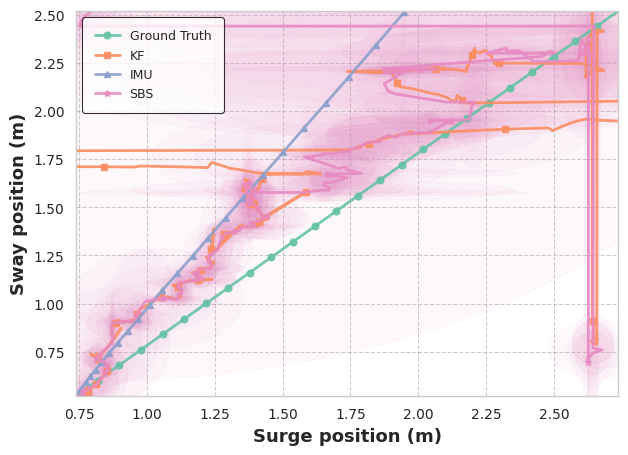

In [148]:

i=0
sns.set_style("whitegrid")
sns.set_context("paper")
palette = sns.color_palette("Set2")
markers = ['o', 's', '^',"*"]
sns.despine()

# --- Thesis-level font settings (bold legends, consistent sizes) ---
plt.rcParams.update({
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.title_fontsize': 12,
    'legend.edgecolor': 'black'
})
#plt.figure(figsize=(7, 5))
fig, ax = plt.subplots(1,1,figsize=(7, 5),sharey=True)
ax.plot(cumulative_displacement_y,cumulative_displacement_x,label="Ground Truth",color=palette[i],marker=markers[i],markevery=40,linewidth=2,alpha=0.9)



i=1
for case in imus[:]:
    print("i is "+str(i))
    print(case)
    df=pd.read_csv(case)



    if("IMU_only" in case):
        plt.plot(-df["Pose_Y"]+origin_y,-df["Pose_X"]+origin_x,label="IMU",markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])

        gt_interp_y=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
        gt_interp_x=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
        gt_interp_z=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)
        rmse_val_imu_x=np.sqrt(((gt_interp_x -(origin_y+df["Pose_Y"])) ** 2).mean())
        rmse_val_imu_y=np.sqrt(((gt_interp_y -(origin_x+df["Pose_X"])) ** 2).mean())
        rmse_val_imu_z=np.sqrt(((gt_interp_z -(df["Pose_Z"]-df["Pose_Z"][0])) ** 2).mean())
        #print(df["Pose_Z"])
        print("IMU error _X",rmse_val_imu_x)
        print("IMU_x_SD",np.std(df["Pose_Y"]))
        print("IMU error _Y",rmse_val_imu_y)
        print("IMU_y_SD",np.std(df["Pose_X"]))
        print("IMU error _Z",rmse_val_imu_z)
        print("IMU_z_SD",np.std(df["Pose_Z"]))

        
        mae_val_imu_x = np.abs(gt_interp_x - (6.75 - df["Pose_Y"])).mean()
        mae_val_imu_y = np.abs(gt_interp_y - (1 - df["Pose_X"])).mean()
        mae_val_imu_z = np.abs(gt_interp_z - (df["Pose_Z"] - df["Pose_Z"][0])).mean()


        print("IMU error _X (MAE):", mae_val_imu_x)
        print("IMU error _Y (MAE):", mae_val_imu_y)
        print("IMU error _Z (MAE):", mae_val_imu_z)
        
    else:
        if("vel_only" in case):
            #ax.scatter(df["Pose_Y"],df["Pose_X"],label="KF with velocities",marker="+")
            print("ignore")
        elif("ptn_only" in case):
            #ax.scatter(df["Pose_Y"],df["Pose_X"],label="KF with positions",marker="+")
            print("ignore")    
        else:
            ax.plot(df["Pose_Y"],df["Pose_X"],label="KF",markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])

            i+=1 
            #print(df["Pose_X"])
        gt_interp_y=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
        gt_interp_x=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
        gt_interp_z=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)
        rmse_val_imu_x=np.sqrt(((gt_interp_x[:]-(df["Pose_Y"][:])) ** 2).mean())
        print((df["Pose_Y"]))
        rmse_val_imu_y=np.sqrt(((gt_interp_y [:]-(df["Pose_X"][:])) ** 2).mean())
        rmse_val_imu_z=np.sqrt(((gt_interp_z[:] -(df["Pose_Z"][:]-df["Pose_Z"][0])) ** 2).mean())
        #print(df["Pose_Z"])
        print("KF error _X",rmse_val_imu_x)
        print("KF_x_SD",np.std(df["Pose_Y"]))
        print("KF error _Y",rmse_val_imu_y)
        print("KF_y_SD",np.std(df["Pose_X"]))
        print("KF error _Z",rmse_val_imu_z)
        print("KF_z_SD",np.std(df["Pose_Z"]))

        mae_val_imu_x = np.abs(gt_interp_y - (df["Pose_Y"])).mean()
        mae_val_imu_y = np.abs(gt_interp_x - (df["Pose_X"])).mean()
        mae_val_imu_z = np.abs(gt_interp_z - (df["Pose_Z"] - df["Pose_Z"][0])).mean()


        print("IMU error _X (MAE):", mae_val_imu_x)
        print("IMU error _Y (MAE):", mae_val_imu_y)
        print("IMU error _Z (MAE):", mae_val_imu_z)

    print(len(df))
    plt.legend()
    #plt.legend(["Q=1, R=1","Q=0.0001, R=1","Q=0.0001, R=100","Q=0.01, R=1"])
    plt.xlabel("X position (m)")
    plt.ylabel("Y position (m)")
    #plt.xlim(0,5)
    #plt.ylim(0,7)
    #i+=1
i+=1
for case in confidence_cases[:1]:
    #print(case)
    df=pd.read_csv(case)
    #plt.title("6th Nov-1205 run, Different localization methods")
    #plt.title("13th Nov- Different localization methods")

    
    ax.plot(df["Sonar_distance_2"]/1000,df["Sonar_distance_1"]/1000,label="SBS",markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])
    #i+=1
    print(len(df))
    plot_ellipses(ax,df)
    gt_interp_y=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
    gt_interp_x=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
    gt_interp_z=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)
    rmse_val_imu_x=np.sqrt(((gt_interp_x-df["Sonar_distance_2"]/1000).mean())**2)
    rmse_val_imu_y=np.sqrt(((gt_interp_y-df["Sonar_distance_1"]/1000).mean())**2)
    rmse_val_imu_z=np.sqrt(((gt_interp_z-(df["Sonar_distance_3"]-df["Sonar_distance_3"][0])/1000).mean())**2)
    #print(df["Pose_Z"])
    print("SBS error _X",rmse_val_imu_x)
    print("SBS_x_SD",np.std(df["Sonar_distance_2"]/1000))
    print("SBS error _Y",rmse_val_imu_y)
    print("SBS_y_SD",np.std(df["Sonar_distance_1"]/1000))
    print("SBS error _Z",rmse_val_imu_z)
    print("SBS_z_SD",np.std(df["Sonar_distance_3"]/1000))


    mae_val_imu_x = np.abs(gt_interp_x - (df["Sonar_distance_2"]/1000)).mean()
    mae_val_imu_y = np.abs(gt_interp_y - (df["Sonar_distance_1"]/1000)).mean()
    mae_val_imu_z = np.abs(gt_interp_z - (df["Sonar_distance_3"]-df["Sonar_distance_3"][0])/1000).mean()


    print("IMU error _X (MAE):", mae_val_imu_x)
    print("IMU error _Y (MAE):", mae_val_imu_y)
    print("IMU error _Z (MAE):", mae_val_imu_z)
    #plt.legend()
    #plt.legend(["Q=1, R=1","Q=0.0001, R=1","Q=0.0001, R=100","Q=0.01, R=1"])

plt.xlim(origin_y,origin_y+gt)
plt.ylim(origin_x,origin_x+gt)
plt.legend(
fontsize=9,
loc='upper left',
frameon=True,
fancybox=True,
borderpad=1,
edgecolor='black'
)
#plt.xlim([0,70])

plt.xlabel("Surge position (m)",fontsize=13, fontweight='bold')
plt.ylabel("Sway position (m)",fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4, color='gray')

In [110]:
i

3

/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_6thNov_1205_best_t2_.csv
1255
/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_6thNov_1205_best_t2_IMU_only.csv
1498
/home/saab/Desktop/2024_UWR/Analysis/confidence_case_6thNov_1205_best_t2_.csv
544


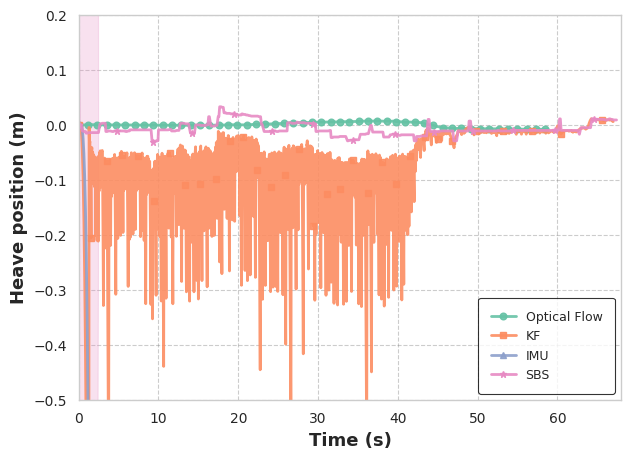

In [115]:
cumulative_displacement_zi=0
i=0
fig, ax = plt.subplots(1,1,figsize=(7, 5),sharey=True)
ax.plot(np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_z,label="Optical Flow",markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])

i=1
for case in imus[:2]:
    print(case)
    df=pd.read_csv(case)


    if(i==1):
        ax.plot(df["Timestamp"]-df["Timestamp"][0],df["Pose_Z"]-df["Pose_Z"][0],label="KF",markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])
        #print(df["Pose_Z"])

    elif("imu_only" in case or "IMU_only" in case):
        ax.plot(df["Timestamp"]-df["Timestamp"][0],df["Pose_Z"]-df["Pose_Z"][0],label="IMU",markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])




        
    print(len(df))
    plt.legend()
    #plt.legend(["Q=1, R=1","Q=0.0001, R=1","Q=0.0001, R=100","Q=0.01, R=1"])
    plt.xlabel("X position (m)")
    plt.ylabel("Y position (m)")
    #plt.xlim(0,5)
    #plt.ylim(0,7)
    i+=1
for case in confidence_cases[:1]:
    print(case)
    df=pd.read_csv(case)
    #plt.title("6th Nov-1205 run, Different localization methods")
    #plt.title("13th Nov- Different localization methods")

    
    ax.plot(df["Timestamp"]-df["Timestamp"][0],(df["Sonar_distance_3"]-df["Sonar_distance_3"][0])/1000,label="SBS",markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])
    print(len(df))
    plot_ellipses(ax,df,s1="Sonar_distance_3",s2="Sonar_distance_3",c1="Confidence_3",rezero=True,c2="Confidence_3",scale=5)
    
plt.legend(
fontsize=9,
loc='lower right',
frameon=True,
fancybox=True,
borderpad=1,
edgecolor='black'
)
plt.ylim([-0.5,0.2])
plt.xlim([0,68])
plt.xlabel("Time (s)",fontsize=13, fontweight='bold')
plt.ylabel("Heave position (m)",fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4, color='gray')

In [112]:
for csv in cases[:]:
    print(csv)
    df=pd.read_csv(csv)
    gt_interp_x=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
    gt_interp_y=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
    gt_interp_z=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)
    rmse_val_sbs_x = np.sqrt(((gt_interp_y[:] - df["Sonar_distance_2"][:] / 1000) ** 2).mean())
    rmse_val_sbs_y = np.sqrt(((gt_interp_x - df["Sonar_distance_1"] / 1000) ** 2).mean())
    rmse_val_kf_y=np.sqrt(((gt_interp_x[:] - df["Pose_X"][:]) ** 2).mean())
    rmse_val_kf_x = np.sqrt(((gt_interp_y[:] - df["Pose_Y"][:]) ** 2).mean())
    rmse_val_kf_z=np.sqrt(((gt_interp_z[:] - (df["Pose_Z"][:]-df["Pose_Z"][0])) ** 2).mean())
    rmse_val_sbs_z=np.sqrt(((gt_interp_z[:] - (df["Sonar_distance_3"][:]-df["Sonar_distance_3"][0])/1000) ** 2).mean())
    #rmse_val_imu_z = np.sqrt(((gt_interp_z - (df["Sonar_distance_3"] - df["Sonar_distance_3"][0]) / 1000) ** 2).mean())

    print("KF error _X",rmse_val_kf_x,end=" ")
    print("KF_x_SD",np.std(df["Pose_Y"]))
    print("KF error _Y",rmse_val_kf_y,end=" ")
    print("KF_y_SD",np.std(df["Pose_X"]))
    print("KF error _Z",rmse_val_kf_z,end=" ")
    print("KF_z_SD",np.std(df["Pose_Z"]))
    print("SBS error _X",rmse_val_sbs_x,end=" ")
    print("SBS_x_SD",np.std(df["Sonar_distance_2"]/1000))
    print("SBS error _Y",rmse_val_sbs_y,end=" ")
    print("SBS_y_SD",np.std(df["Sonar_distance_1"]/1000))
    print("SBS error _Z",rmse_val_sbs_z,end=" ")
    print("SBS_z_SD",np.std(df["Sonar_distance_3"]/1000))

/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_best_t2_.csv
KF error _X 1.385130155980035 KF_x_SD 1.7305991039400634
KF error _Y 0.1062220252708005 KF_y_SD 0.2204535217070985
KF error _Z 0.0773595278138649 KF_z_SD 0.07538708427127731
SBS error _X 1.8690679187678354 SBS_x_SD 1.7989327268351838
SBS error _Y 0.10739136565129932 SBS_y_SD 0.22019598579598315
SBS error _Z 0.018362116264112993 SBS_z_SD 0.01320258201054448
/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_t2_ptn_only.csv
KF error _X 1.409547350916638 KF_x_SD 1.7565975743309497
KF error _Y 0.09788321552237976 KF_y_SD 0.2270090323221798
KF error _Z 0.9392100362558081 KF_z_SD 0.6917914532639996
SBS error _X 1.760928696697179 SBS_x_SD 1.8136137412900237
SBS error _Y 0.11067918453670794 SBS_y_SD 0.23003678545158332
SBS error _Z 0.01742464946531031 SBS_z_SD 0.012451745692673964
/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_t2_vel_only.csv
KF error _X 2.8108832225963853 KF_x_SD 1.88741358393543

/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_best_t2_.csv


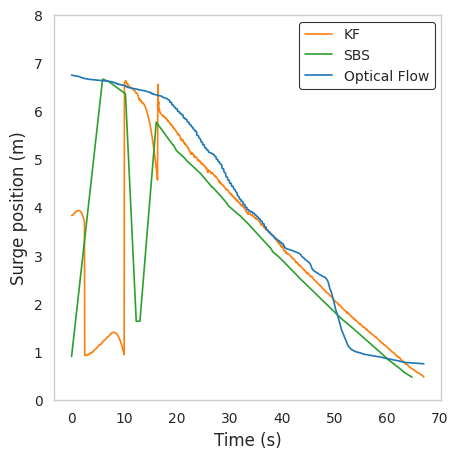

In [113]:
color_scheme=["tab:blue","tab:orange","tab:green"]
percentages=[10,20,30]
plt.figure(figsize=(5,5))
#plt.title("Expt_6thNov_1205_Best")
i=0
for case,imu in zip(cases[:1],imus[:1]):
    print(case)
    df1=pd.read_csv(case)
    df2=pd.read_csv(imu)
    times=np.linspace(0,df2['Timestamp'][len(df2)-1]-df2["Timestamp"][0],len(gt_df))
    
    #if(i==0 or i==7):
    plt.plot(np.array(df2['Timestamp']-df2["Timestamp"][0]),np.array(df2["Pose_Y"]),label="KF",color="tab:orange")
    
    
    #plt.legend()
    plt.ylim(0,8)
    #plt.show()
    i+=1
plt.plot(np.array(df1['Timestamp']-df1["Timestamp"][0]),np.array(df1["Sonar_distance_2"])/1000,label="SBS",color="tab:green")
plt.plot(times,cumulative_displacement_y,label='Optical Flow',color="tab:blue")
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Surge position (m)")
plt.grid()

In [114]:
corrected_imus=[imus[0],imus[2],imus[3]]

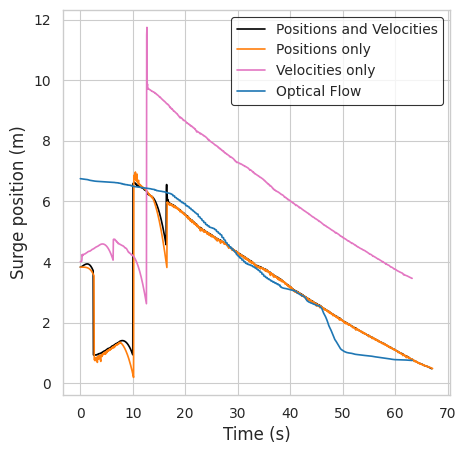

In [116]:
labels=["Positions and Velocities","Positions only","Velocities only"]
colors=["black","tab:orange","tab:pink"]
plt.figure(figsize=(5,5))
i=0
for case,imu,label in zip(cases[:],corrected_imus[:],labels[:]):
    df1=pd.read_csv(case)
    df2=pd.read_csv(imu)
    #plt.title(case)
    #plt.plot(np.array(df1["Timestamp"]-df1["Timestamp"][0]),np.array(df1["Sonar_distance_3"])/1000,label="SONAR")
    plt.plot(np.array(df2["Timestamp"]-df2["Timestamp"][0]),np.array(df2["Pose_Y"]),label=label,color=colors[i])
    
    
    plt.xlabel("Time (s)")
    plt.ylabel("Surge position (m)")
    #plt.ylim(0.5,1)
    #plt.show
    i+=1
plt.plot(np.linspace(0,np.array(df2["Timestamp"][len(df2)-1]-df2["Timestamp"][0]),len(cumulative_displacement_y)),cumulative_displacement_y,color="tab:blue",label="Optical Flow")
plt.legend()
plt.grid("on")

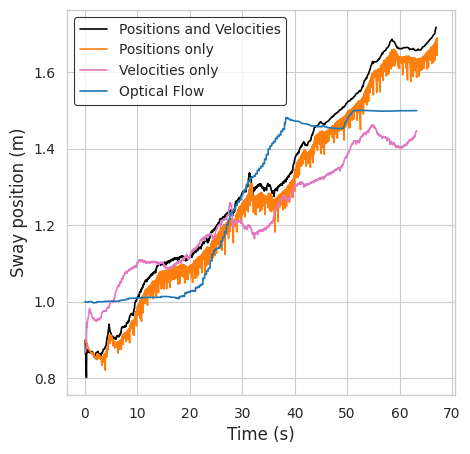

In [117]:
labels=["Positions and Velocities","Positions only","Velocities only"]
colors=["black","tab:orange","tab:pink"]
plt.figure(figsize=(5,5))
i=0
for case,imu,label in zip(cases[:],corrected_imus[:],labels[:]):
    df1=pd.read_csv(case)
    df2=pd.read_csv(imu)
    #plt.title(case)
    #plt.plot(np.array(df1["Timestamp"]-df1["Timestamp"][0]),np.array(df1["Sonar_distance_3"])/1000,label="SONAR")
    plt.plot(np.array(df2["Timestamp"]-df2["Timestamp"][0]),np.array(df2["Pose_X"]),label=label,color=colors[i])
    
    
    plt.xlabel("Time (s)")
    plt.ylabel("Sway position (m)")
    #plt.ylim(0.5,1)
    #plt.show
    i+=1
plt.plot(np.linspace(0,np.array(df2["Timestamp"][len(df2)-1]-df2["Timestamp"][0]),len(cumulative_displacement_x)),cumulative_displacement_x,color="tab:blue",label="Optical Flow")
plt.legend()
plt.grid("on")

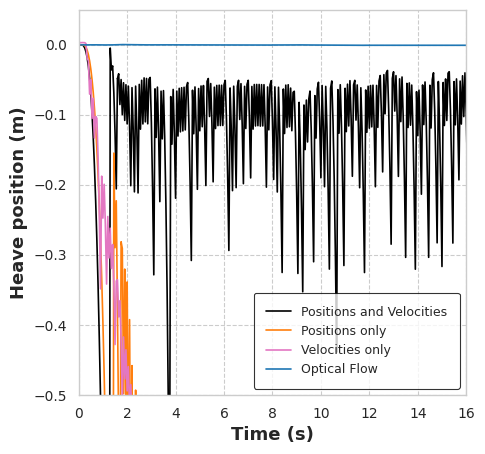

In [119]:
labels=["Positions and Velocities","Positions only","Velocities only"]
colors=["black","tab:orange","tab:pink"]
plt.figure(figsize=(5,5))
i=0
for case,imu,label in zip(cases[:],corrected_imus[:],labels[:]):
    df1=pd.read_csv(case)
    df2=pd.read_csv(imu)
    #plt.title(case)
    #plt.plot(np.array(df1["Timestamp"]-df1["Timestamp"][0]),np.array(df1["Sonar_distance_3"])/1000,label="SONAR")
    plt.plot(np.array(df2["Timestamp"]-df2["Timestamp"][0]),np.array(df2["Pose_Z"]-df2["Pose_Z"][0]),label=label,color=colors[i])
    
    
    plt.xlabel("Time (s)")
    plt.ylabel("Heave position (m)")
    #plt.ylim(0.5,1)
    #plt.show
    i+=1
plt.plot(np.linspace(0,np.array(df2["Timestamp"][len(df2)-1]-df2["Timestamp"][0]),len(cumulative_displacement_z)),cumulative_displacement_z,color="tab:blue",label="Optical Flow")
plt.legend(
fontsize=9,
loc='lower right',
frameon=True,
fancybox=True,
borderpad=1,
edgecolor='black'
)
plt.ylim([-0.5,0.05])
plt.xlim([0,16])
plt.xlabel("Time (s)",fontsize=13, fontweight='bold')
plt.ylabel("Heave position (m)",fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4, color='gray')

# 1302 (Thruster) dataset calculations

In [124]:
cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/output_case*1302*t2*"))
confidence_cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/confidence_case*1302*t2*"))
imus=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/output*IMU*1302*t2*"))
gt=sorted(glob("/home/saab/Desktop/2024_UWR/Analysis/gt/13*/*corrected*1302.csv"))
gt

['/home/saab/Desktop/2024_UWR/Analysis/gt/13Nov/output_corrected_1302.csv']

In [125]:
#1302
gt_df=pd.read_csv(gt[0])
div_flows_mean=gt_df["Z"].to_numpy()
#displacements=np.sqrt(gt_df["X"].to_numpy()**2 + gt_df["Y"].to_numpy()**2)
displacements_x=gt_df["X"].to_numpy()
displacements_z=gt_df["Y"].to_numpy()
# Calculate cumulative displacement
displacements=np.sqrt(gt_df["X"].to_numpy()**2 + gt_df["Y"].to_numpy()**2)
cumulative_displacement_x = np.cumsum(div_flows_mean)
cumulative_displacement_y =np.cumsum(displacements)
cumulative_displacement_z =np.cumsum(displacements_z)*0.001
cumulative_displacement_x*=-0.1/abs(cumulative_displacement_x[0]-cumulative_displacement_x[cumulative_displacement_x.shape[0]-1])
cumulative_displacement_y*=6/abs(cumulative_displacement_y[0]-cumulative_displacement_y[cumulative_displacement_y.shape[0]-1])
cumulative_displacement_x+=1.28
cumulative_displacement_y=7.65-cumulative_displacement_y

/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_1302_t2_.csv
KF error _X 0.9617357800044569
KF_x_SD 1.8647556579076359
KF error _Y 0.09195658057108512
KF_y_SD 0.04681962416713861
KF error _Z 0.7984503763112996
KF_z_SD 0.1041024718390576
IMU error _X (MAE): 0.7119938421993706
IMU error _Y (MAE): 0.08389605583577128
IMU error _Z (MAE): 0.09522500331572452
339
/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_1302_t2_imu_only_.csv
IMU error _X 4.0106571497086065
IMU_x_SD 0.11807056276486816
IMU error _Y 1.2884515744245764
IMU_y_SD 0.9213707530803974
IMU error _Z 450.74918867998684
IMU_z_SD 322.9257198455405
337
/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_13thNov_1302_t2_ptn_only.csv
ignore
KF error _X 0.9777687552225229
KF_x_SD 1.846859191538499
KF error _Y 0.08557680771695172
KF_y_SD 0.045822108313795795
KF error _Z 0.8561705155415683
KF_z_SD 0.8019181900663068
IMU error _X (MAE): 0.7310966513454655
IMU error _Y (MAE): 0.07844553076407634
IMU error _Z (MAE): 1.1932069383

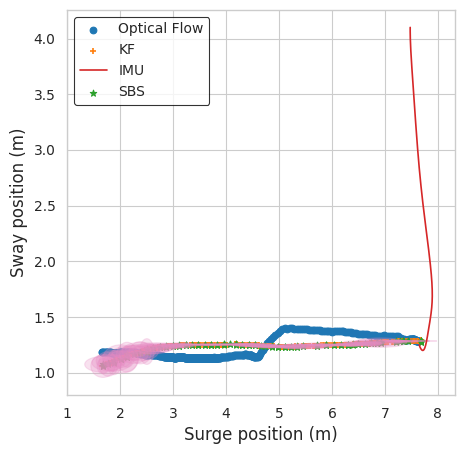

In [126]:
i=0
fig, ax = plt.subplots(1,1,figsize=(5, 5),sharey=True)
ax.scatter(cumulative_displacement_y,cumulative_displacement_x,label="Optical Flow",color="tab:blue")

i=1
for case in imus[:]:
    print(case)
    df=pd.read_csv(case)



    if("imu_only" in case):
        plt.plot(7.65-df["Pose_Y"],1.25-df["Pose_X"],label="IMU",color="tab:red")

        gt_interp_x=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
        gt_interp_y=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
        gt_interp_z=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)
        rmse_val_imu_x=np.sqrt(((gt_interp_y -(7.65-df["Pose_Y"])) ** 2).mean())
        rmse_val_imu_y=np.sqrt(((gt_interp_x -(1.25-df["Pose_X"])) ** 2).mean())
        rmse_val_imu_z=np.sqrt(((gt_interp_z -(df["Pose_Z"]-df["Pose_Z"][0])) ** 2).mean())
        #print(df["Pose_Z"])
        print("IMU error _X",rmse_val_imu_x)
        print("IMU_x_SD",np.std(df["Pose_Y"]))
        print("IMU error _Y",rmse_val_imu_y)
        print("IMU_y_SD",np.std(df["Pose_X"]))
        print("IMU error _Z",rmse_val_imu_z)
        
        
        print("IMU_z_SD",np.std(df["Pose_Z"]))

    else:
        if("vel_only" in case or "ptn_only" in case):
            print("ignore")
            #ax.scatter(df["Pose_Y"],df["Pose_X"],label="KF with velocities",marker="+")
        else:
            ax.scatter(df["Pose_Y"],df["Pose_X"],label="KF",marker="+",color="tab:orange")
            #print("ignore")
        
        gt_interp_x=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
        gt_interp_y=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
        gt_interp_z=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)
        rmse_val_imu_x=np.sqrt(((gt_interp_y -(df["Pose_Y"])) ** 2).mean())
        rmse_val_imu_y=np.sqrt(((gt_interp_x -(df["Pose_X"])) ** 2).mean())
        rmse_val_imu_z=np.sqrt(((gt_interp_z -(df["Pose_Z"])) ** 2).mean())
        #print(df["Pose_Z"])
        print("KF error _X",rmse_val_imu_x)
        print("KF_x_SD",np.std(df["Pose_Y"]))
        print("KF error _Y",rmse_val_imu_y)
        print("KF_y_SD",np.std(df["Pose_X"]))
        print("KF error _Z",rmse_val_imu_z)
        print("KF_z_SD",np.std(df["Pose_Z"]))
        mae_val_imu_x = np.abs(gt_interp_y - (df["Pose_Y"])).mean()
        mae_val_imu_y = np.abs(gt_interp_x - (df["Pose_X"])).mean()
        mae_val_imu_z = np.abs(gt_interp_z - (df["Pose_Z"] - df["Pose_Z"][0])).mean()


        print("IMU error _X (MAE):", mae_val_imu_x)
        print("IMU error _Y (MAE):", mae_val_imu_y)
        print("IMU error _Z (MAE):", mae_val_imu_z)

        
    print(len(df))
    plt.legend()
    #plt.legend(["Q=1, R=1","Q=0.0001, R=1","Q=0.0001, R=100","Q=0.01, R=1"])
    plt.xlabel("X position (m)")
    plt.ylabel("Y position (m)")
    #plt.xlim(0,5)
    #plt.ylim(0,7)
    i+=1
for case in confidence_cases[:1]:
    print(case)
    df=pd.read_csv(case)
    #plt.title("6th Nov-1205 run, Different localization methods")
    #plt.title("13th Nov- Different localization methods")

    
    ax.scatter(df["Sonar_distance_2"]/1000,df["Sonar_distance_1"]/1000,label="SBS",color="tab:green",marker="*")
    print(len(df))
    plot_ellipses(ax,df)
    gt_interp_x=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
    gt_interp_y=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
    gt_interp_z=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)
    rmse_val_imu_x=np.sqrt(((gt_interp_y-df["Sonar_distance_2"]/1000).mean())**2)
    rmse_val_imu_y=np.sqrt(((gt_interp_x-df["Sonar_distance_1"]/1000).mean())**2)
    rmse_val_imu_z=np.sqrt(((gt_interp_z-(df["Sonar_distance_3"]-df["Sonar_distance_3"][0])/1000).mean())**2)
    #print(df["Pose_Z"])
    print("SBS error _X",rmse_val_imu_x)
    print("SBS_x_SD",np.std(df["Sonar_distance_2"]/1000))
    print("SBS error _Y",rmse_val_imu_y)
    print("SBS_y_SD",np.std(df["Sonar_distance_1"]/1000))
    print("SBS error _Z",rmse_val_imu_z)
    print("SBS_z_SD",np.std(df["Sonar_distance_3"]/1000))
    plt.legend()
    #plt.legend(["Q=1, R=1","Q=0.0001, R=1","Q=0.0001, R=100","Q=0.01, R=1"])
    plt.xlabel("Surge position (m)")
    plt.ylabel("Sway position (m)")
    #plt.xlim(1,8)
    #plt.ylim(0,2)
    plt.grid("on")

i is 1
/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_1302_t2_.csv
0      7.685000
1      7.685000
2      7.685000
3      7.685000
4      7.685000
         ...   
334    1.780482
335    1.763349
336    1.735197
337    1.688453
338    1.656704
Name: Pose_Y, Length: 339, dtype: float64
KF error _X 0.9617357800044569
KF_x_SD 1.8647556579076359
KF error _Y 0.09195658057108512
KF_y_SD 0.04681962416713861
KF error _Z 0.1402965771747627
KF_z_SD 0.1041024718390576
IMU error _X (MAE): 3.5783339585842806
IMU error _Y (MAE): 2.8245539206315824
IMU error _Z (MAE): 0.09522500331572452
339
i is 2
/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_1302_t2_imu_only_.csv
IMU error _X 3.2104935900422147
IMU_x_SD 0.11807056276486816
IMU error _Y 1.135788540211113
IMU_y_SD 0.9213707530803974
IMU error _Z 450.74918867998684
IMU_z_SD 322.9257198455405
IMU error _X (MAE): 2.9242058890789493
IMU error _Y (MAE): 0.8260765333252081
IMU error _Z (MAE): 314.4775182720913
337
i is 2
/home/saab/Desktop/2024

<Figure size 640x480 with 0 Axes>

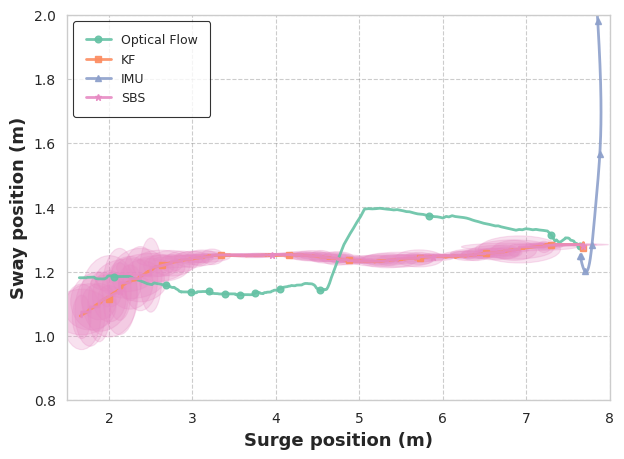

In [135]:

i=0
sns.set_style("whitegrid")
sns.set_context("paper")
palette = sns.color_palette("Set2")
markers = ['o', 's', '^',"*"]
sns.despine()

# --- Thesis-level font settings (bold legends, consistent sizes) ---
plt.rcParams.update({
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.title_fontsize': 12,
    'legend.edgecolor': 'black'
})
#plt.figure(figsize=(7, 5))
fig, ax = plt.subplots(1,1,figsize=(7, 5),sharey=True)
ax.plot(cumulative_displacement_y,cumulative_displacement_x,label="Optical Flow",color=palette[i],marker=markers[i],markevery=40,linewidth=2,alpha=0.9)



i=1
for case in imus[:]:
    print("i is "+str(i))
    print(case)
    df=pd.read_csv(case)



    if("imu_only" in case):
        plt.plot(7.65-df["Pose_Y"],1.25-df["Pose_X"],label="IMU",markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])

        gt_interp_y=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
        gt_interp_x=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
        gt_interp_z=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)
        rmse_val_imu_x=np.sqrt(((gt_interp_x -(6.75-df["Pose_Y"])) ** 2).mean())
        rmse_val_imu_y=np.sqrt(((gt_interp_y -(1-df["Pose_X"])) ** 2).mean())
        rmse_val_imu_z=np.sqrt(((gt_interp_z -(df["Pose_Z"]-df["Pose_Z"][0])) ** 2).mean())
        #print(df["Pose_Z"])
        print("IMU error _X",rmse_val_imu_x)
        print("IMU_x_SD",np.std(df["Pose_Y"]))
        print("IMU error _Y",rmse_val_imu_y)
        print("IMU_y_SD",np.std(df["Pose_X"]))
        print("IMU error _Z",rmse_val_imu_z)
        print("IMU_z_SD",np.std(df["Pose_Z"]))

        
        mae_val_imu_x = np.abs(gt_interp_x - (6.75 - df["Pose_Y"])).mean()
        mae_val_imu_y = np.abs(gt_interp_y - (1 - df["Pose_X"])).mean()
        mae_val_imu_z = np.abs(gt_interp_z - (df["Pose_Z"] - df["Pose_Z"][0])).mean()


        print("IMU error _X (MAE):", mae_val_imu_x)
        print("IMU error _Y (MAE):", mae_val_imu_y)
        print("IMU error _Z (MAE):", mae_val_imu_z)
        
    else:
        if("vel_only" in case):
            #ax.scatter(df["Pose_Y"],df["Pose_X"],label="KF with velocities",marker="+")
            print("ignore")
        elif("ptn_only" in case):
            #ax.scatter(df["Pose_Y"],df["Pose_X"],label="KF with positions",marker="+")
            print("ignore")    
        else:
            ax.plot(df["Pose_Y"],df["Pose_X"],label="KF",markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])

            i+=1 
            #print(df["Pose_X"])
        gt_interp_y=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
        gt_interp_x=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
        gt_interp_z=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)
        rmse_val_imu_x=np.sqrt(((gt_interp_x[:]-(df["Pose_Y"][:])) ** 2).mean())
        print((df["Pose_Y"]))
        rmse_val_imu_y=np.sqrt(((gt_interp_y [:]-(df["Pose_X"][:])) ** 2).mean())
        rmse_val_imu_z=np.sqrt(((gt_interp_z[:] -(df["Pose_Z"][:]-df["Pose_Z"][0])) ** 2).mean())
        #print(df["Pose_Z"])
        print("KF error _X",rmse_val_imu_x)
        print("KF_x_SD",np.std(df["Pose_Y"]))
        print("KF error _Y",rmse_val_imu_y)
        print("KF_y_SD",np.std(df["Pose_X"]))
        print("KF error _Z",rmse_val_imu_z)
        print("KF_z_SD",np.std(df["Pose_Z"]))

        mae_val_imu_x = np.abs(gt_interp_y - (df["Pose_Y"])).mean()
        mae_val_imu_y = np.abs(gt_interp_x - (df["Pose_X"])).mean()
        mae_val_imu_z = np.abs(gt_interp_z - (df["Pose_Z"] - df["Pose_Z"][0])).mean()


        print("IMU error _X (MAE):", mae_val_imu_x)
        print("IMU error _Y (MAE):", mae_val_imu_y)
        print("IMU error _Z (MAE):", mae_val_imu_z)

    print(len(df))
    plt.legend()
    #plt.legend(["Q=1, R=1","Q=0.0001, R=1","Q=0.0001, R=100","Q=0.01, R=1"])
    plt.xlabel("X position (m)")
    plt.ylabel("Y position (m)")
    #plt.xlim(0,5)
    #plt.ylim(0,7)
    #i+=1
i+=1
for case in confidence_cases[:1]:
    #print(case)
    df=pd.read_csv(case)
    #plt.title("6th Nov-1205 run, Different localization methods")
    #plt.title("13th Nov- Different localization methods")

    
    ax.plot(df["Sonar_distance_2"]/1000,df["Sonar_distance_1"]/1000,label="SBS",markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])
    #i+=1
    print(len(df))
    plot_ellipses(ax,df)
    gt_interp_y=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
    gt_interp_x=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
    gt_interp_z=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)
    rmse_val_imu_x=np.sqrt(((gt_interp_x-df["Sonar_distance_2"]/1000).mean())**2)
    rmse_val_imu_y=np.sqrt(((gt_interp_y-df["Sonar_distance_1"]/1000).mean())**2)
    rmse_val_imu_z=np.sqrt(((gt_interp_z-(df["Sonar_distance_3"]-df["Sonar_distance_3"][0])/1000).mean())**2)
    #print(df["Pose_Z"])
    print("SBS error _X",rmse_val_imu_x)
    print("SBS_x_SD",np.std(df["Sonar_distance_2"]/1000))
    print("SBS error _Y",rmse_val_imu_y)
    print("SBS_y_SD",np.std(df["Sonar_distance_1"]/1000))
    print("SBS error _Z",rmse_val_imu_z)
    print("SBS_z_SD",np.std(df["Sonar_distance_3"]/1000))


    mae_val_imu_x = np.abs(gt_interp_x - (df["Sonar_distance_2"]/1000)).mean()
    mae_val_imu_y = np.abs(gt_interp_y - (df["Sonar_distance_1"]/1000)).mean()
    mae_val_imu_z = np.abs(gt_interp_z - (df["Sonar_distance_3"]-df["Sonar_distance_3"][0])/1000).mean()


    print("IMU error _X (MAE):", mae_val_imu_x)
    print("IMU error _Y (MAE):", mae_val_imu_y)
    print("IMU error _Z (MAE):", mae_val_imu_z)
    #plt.legend()
    #plt.legend(["Q=1, R=1","Q=0.0001, R=1","Q=0.0001, R=100","Q=0.01, R=1"])

plt.xlim(1.5,8)
plt.ylim(0.8,2)
plt.legend(
fontsize=9,
loc='upper left',
frameon=True,
fancybox=True,
borderpad=1,
edgecolor='black'
)
#plt.xlim([0,70])

plt.xlabel("Surge position (m)",fontsize=13, fontweight='bold')
plt.ylabel("Sway position (m)",fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4, color='gray')

/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_1302_t2_.csv
339
/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_1302_t2_imu_only_.csv
337
/home/saab/Desktop/2024_UWR/Analysis/confidence_case_1302_t2_.csv
132


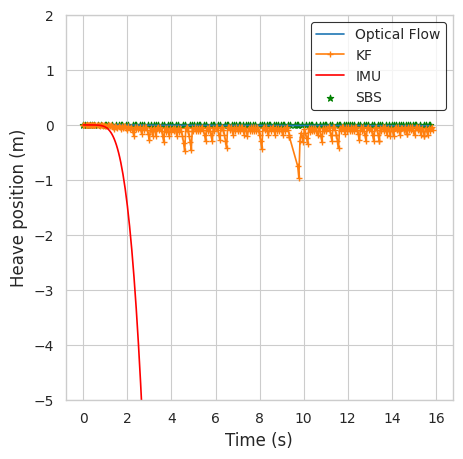

In [ ]:
cumulative_displacement_zi=0
fig, ax = plt.subplots(1,1,figsize=(5, 5),sharey=True)
ax.plot(np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_z,label="Optical Flow")

i=1
for case in imus[:2]:
    print(case)
    df=pd.read_csv(case)


    if(i==1):
        ax.plot(df["Timestamp"]-df["Timestamp"][0],df["Pose_Z"]-df["Pose_Z"][0],label="KF",marker="+")
        #print(df["Pose_Z"])

    elif("imu_only" in case or "IMU_only" in case):
        ax.plot(df["Timestamp"]-df["Timestamp"][0],df["Pose_Z"]-df["Pose_Z"][0],label="IMU",color="red")




        
    print(len(df))
    plt.legend()
    #plt.legend(["Q=1, R=1","Q=0.0001, R=1","Q=0.0001, R=100","Q=0.01, R=1"])
    plt.xlabel("X position (m)")
    plt.ylabel("Y position (m)")
    #plt.xlim(0,5)
    #plt.ylim(0,7)
    i+=1
for case in confidence_cases[:1]:
    print(case)
    df=pd.read_csv(case)
    #plt.title("6th Nov-1205 run, Different localization methods")
    #plt.title("13th Nov- Different localization methods")

    
    ax.scatter(df["Timestamp"]-df["Timestamp"][0],(df["Sonar_distance_3"]-df["Sonar_distance_3"][0])/1000,label="SBS",color="green",marker="*")
    print(len(df))
    plot_ellipses(ax,df,s1="Sonar_distance_3",s2="Sonar_distance_3",c1="Confidence_3",rezero=True,c2="Confidence_3",scale=5)
    
    plt.legend()
    #plt.legend(["Q=1, R=1","Q=0.0001, R=1","Q=0.0001, R=100","Q=0.01, R=1"])
    plt.xlabel("Time (s)")
    plt.ylabel("Heave position (m)")
    #plt.xlim(1,8)
    plt.ylim(-5,2)
    plt.grid("on")

/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_1302_t2_.csv
339
/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_1302_t2_imu_only_.csv
337
/home/saab/Desktop/2024_UWR/Analysis/confidence_case_1302_t2_.csv
132


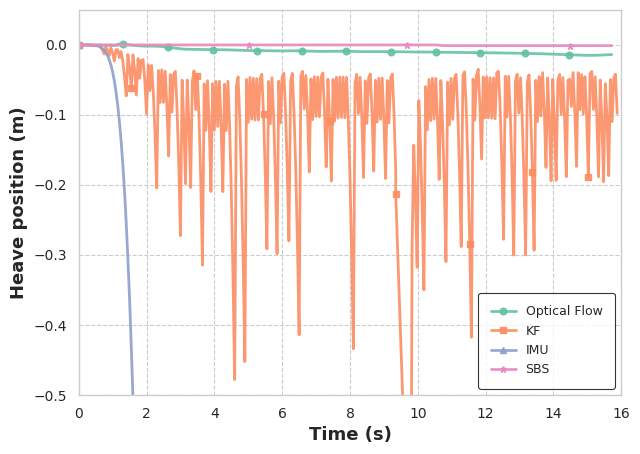

In [ ]:
cumulative_displacement_zi=0
i=0
fig, ax = plt.subplots(1,1,figsize=(7, 5),sharey=True)
ax.plot(np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_z,label="Optical Flow",markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])

i=1
for case in imus[:2]:
    print(case)
    df=pd.read_csv(case)


    if(i==1):
        ax.plot(df["Timestamp"]-df["Timestamp"][0],df["Pose_Z"]-df["Pose_Z"][0],label="KF",markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])
        #print(df["Pose_Z"])

    elif("imu_only" in case or "IMU_only" in case):
        ax.plot(df["Timestamp"]-df["Timestamp"][0],df["Pose_Z"]-df["Pose_Z"][0],label="IMU",markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])




        
    print(len(df))
    plt.legend()
    #plt.legend(["Q=1, R=1","Q=0.0001, R=1","Q=0.0001, R=100","Q=0.01, R=1"])
    plt.xlabel("X position (m)")
    plt.ylabel("Y position (m)")
    #plt.xlim(0,5)
    #plt.ylim(0,7)
    i+=1
for case in confidence_cases[:1]:
    print(case)
    df=pd.read_csv(case)
    #plt.title("6th Nov-1205 run, Different localization methods")
    #plt.title("13th Nov- Different localization methods")

    
    ax.plot(df["Timestamp"]-df["Timestamp"][0],(df["Sonar_distance_3"]-df["Sonar_distance_3"][0])/1000,label="SBS",markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])
    print(len(df))
    plot_ellipses(ax,df,s1="Sonar_distance_3",s2="Sonar_distance_3",c1="Confidence_3",rezero=True,c2="Confidence_3",scale=5)
    
plt.legend(
fontsize=9,
loc='lower right',
frameon=True,
fancybox=True,
borderpad=1,
edgecolor='black'
)
plt.ylim([-0.5,0.05])
plt.xlim([0,16])
plt.xlabel("Time (s)",fontsize=13, fontweight='bold')
plt.ylabel("Heave position (m)",fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4, color='gray')

In [26]:
for csv in cases[:]:
    print(csv)
    df=pd.read_csv(csv)
    gt_interp_x=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
    gt_interp_y=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
    gt_interp_z=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)
    rmse_val_sbs_x = np.sqrt(((gt_interp_y[:] - df["Sonar_distance_2"][:] / 1000) ** 2).mean())
    rmse_val_sbs_y = np.sqrt(((gt_interp_x - df["Sonar_distance_1"] / 1000) ** 2).mean())
    rmse_val_kf_y=np.sqrt(((gt_interp_x[:] - df["Pose_X"][:]) ** 2).mean())
    rmse_val_kf_x = np.sqrt(((gt_interp_y[:] - df["Pose_Y"][:]) ** 2).mean())
    rmse_val_kf_z=np.sqrt(((gt_interp_z[:] - (df["Pose_Z"][:]-df["Pose_Z"][0])) ** 2).mean())
    rmse_val_sbs_z=np.sqrt(((gt_interp_z[:] - (df["Sonar_distance_3"][:]-df["Sonar_distance_3"][0])/1000) ** 2).mean())
    #rmse_val_imu_z = np.sqrt(((gt_interp_z - (df["Sonar_distance_3"] - df["Sonar_distance_3"][0]) / 1000) ** 2).mean())

    print("KF error _X",rmse_val_kf_x,end=" ")
    print("KF_x_SD",np.std(df["Pose_Y"]))
    print("KF error _Y",rmse_val_kf_y,end=" ")
    print("KF_y_SD",np.std(df["Pose_X"]))
    print("KF error _Z",rmse_val_kf_z,end=" ")
    print("KF_z_SD",np.std(df["Pose_Z"]))
    print("SBS error _X",rmse_val_sbs_x,end=" ")
    print("SBS_x_SD",np.std(df["Sonar_distance_2"]/1000))
    print("SBS error _Y",rmse_val_sbs_y,end=" ")
    print("SBS_y_SD",np.std(df["Sonar_distance_1"]/1000))
    print("SBS error _Z",rmse_val_sbs_z,end=" ")
    print("SBS_z_SD",np.std(df["Sonar_distance_3"]/1000))

/home/saab/Desktop/2024_UWR/Analysis/output_case_1302_t2_.csv
KF error _X 0.9660986114581697 KF_x_SD 1.6203400915497335
KF error _Y 0.08978109264474414 KF_y_SD 0.027853035441474248
KF error _Z 0.061822966976906944 KF_z_SD 0.05741679828744036
SBS error _X 0.8961747705843323 SBS_x_SD 1.6140854035645078
SBS error _Y 0.09035664556165343 SBS_y_SD 0.030899999999999993
SBS error _Z 0.008993499557411551 SBS_z_SD 0.00040000000000000034
/home/saab/Desktop/2024_UWR/Analysis/output_case_13thNov_1302_t2_ptn_only.csv
KF error _X 0.9615751301844795 KF_x_SD 1.6277646678771036
KF error _Y 0.07986517229611453 KF_y_SD 0.02999664997606889
KF error _Z 2.0285607295074737 KF_z_SD 1.575903801849414
SBS error _X 0.8961582744987778 SBS_x_SD 1.6140854035645078
SBS error _Y 0.09035568716186727 SBS_y_SD 0.030899999999999993
SBS error _Z 0.008993133961418284 SBS_z_SD 0.00040000000000000034
/home/saab/Desktop/2024_UWR/Analysis/output_case_13thNov_1302_t2_vel_only.csv
KF error _X 0.7389310915319277 KF_x_SD 1.79282342

In [27]:
imus

['/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_1302_t2_.csv',
 '/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_1302_t2_imu_only_.csv',
 '/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_13thNov_1302_t2_ptn_only.csv',
 '/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_13thNov_1302_t2_vel_only.csv']

In [28]:
corrected_imus=[imus[0],imus[2],imus[3]]

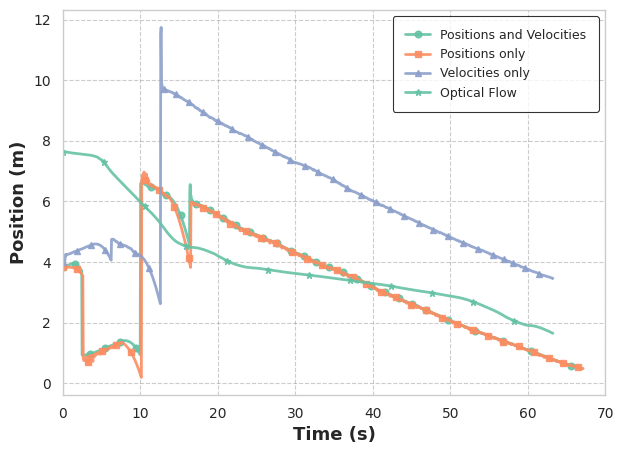

In [144]:
labels=["Positions and Velocities","Positions only","Velocities only"]
#colors=["black","tab:orange","tab:pink"]
i=1
plt.figure(figsize=(7,5))
i=0
for case,imu,label in zip(cases[:],corrected_imus[:],labels[:]):
    df1=pd.read_csv(case)
    df2=pd.read_csv(imu)
    #plt.title(case)
    #plt.plot(np.array(df1["Timestamp"]-df1["Timestamp"][0]),np.array(df1["Sonar_distance_3"])/1000,label="SONAR")
    plt.plot(np.array(df2["Timestamp"]-df2["Timestamp"][0]),np.array(df2["Pose_Y"]),label=label,markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])
    
    
    plt.xlabel("Time (s)")
    plt.ylabel("Surge position (m)")
    #plt.ylim(0.5,1)
    #plt.show
    i+=1
plt.plot(np.linspace(0,np.array(df2["Timestamp"][len(df2)-1]-df2["Timestamp"][0]),len(cumulative_displacement_y)),cumulative_displacement_y,color=palette[0],label="Optical Flow",markevery=40,linewidth=2,alpha=0.9,marker=markers[i])
plt.legend(
fontsize=9,
loc='upper right',
frameon=True,
fancybox=True,
borderpad=1,
edgecolor='black'
)
#plt.ylim([-0.5,0.05])
plt.xlim([0,70])
plt.xlabel("Time (s)",fontsize=13, fontweight='bold')
plt.ylabel("Position (m)",fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4, color='gray')

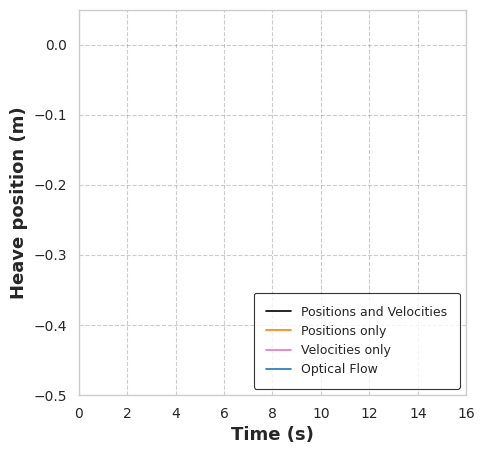

In [120]:
labels=["Positions and Velocities","Positions only","Velocities only"]
colors=["black","tab:orange","tab:pink"]
plt.figure(figsize=(5,5))
i=0
for case,imu,label in zip(cases[:],corrected_imus[:],labels[:]):
    df1=pd.read_csv(case)
    df2=pd.read_csv(imu)
    #plt.title(case)
    #plt.plot(np.array(df1["Timestamp"]-df1["Timestamp"][0]),np.array(df1["Sonar_distance_3"])/1000,label="SONAR")
    plt.plot(np.array(df2["Timestamp"]-df2["Timestamp"][0]),np.array(df2["Pose_X"]),label=label,color=colors[i])
    
    
    plt.xlabel("Time (s)")
    plt.ylabel("Sway position (m)")
    #plt.ylim(0.5,1)
    #plt.show
    i+=1
plt.plot(np.linspace(0,np.array(df2["Timestamp"][len(df2)-1]-df2["Timestamp"][0]),len(cumulative_displacement_x)),cumulative_displacement_x,color="tab:blue",label="Optical Flow")
plt.legend(
fontsize=9,
loc='lower right',
frameon=True,
fancybox=True,
borderpad=1,
edgecolor='black'
)
plt.ylim([-0.5,0.05])
plt.xlim([0,16])
plt.xlabel("Time (s)",fontsize=13, fontweight='bold')
plt.ylabel("Heave position (m)",fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4, color='gray')

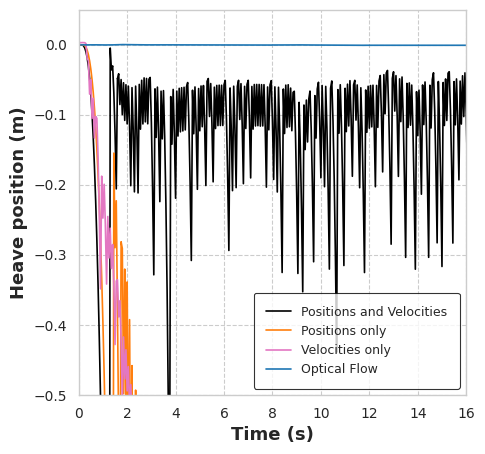

In [121]:
labels=["Positions and Velocities","Positions only","Velocities only"]
colors=["black","tab:orange","tab:pink"]
plt.figure(figsize=(5,5))
i=0
for case,imu,label in zip(cases[:],corrected_imus[:],labels[:]):
    df1=pd.read_csv(case)
    df2=pd.read_csv(imu)
    #plt.title(case)
    #plt.plot(np.array(df1["Timestamp"]-df1["Timestamp"][0]),np.array(df1["Sonar_distance_3"])/1000,label="SONAR")
    plt.plot(np.array(df2["Timestamp"]-df2["Timestamp"][0]),np.array(df2["Pose_Z"]-df2["Pose_Z"][0]),label=label,color=colors[i])
    
    
    plt.xlabel("Time (s)")
    plt.ylabel("Heave position (m)")
    #plt.ylim(0.5,1)
    #plt.show
    i+=1
plt.plot(np.linspace(0,np.array(df2["Timestamp"][len(df2)-1]-df2["Timestamp"][0]),len(cumulative_displacement_z)),cumulative_displacement_z,color="tab:blue",label="Optical Flow")
plt.legend(
fontsize=9,
loc='lower right',
frameon=True,
fancybox=True,
borderpad=1,
edgecolor='black'
)
plt.ylim([-0.5,0.05])
plt.xlim([0,16])
plt.xlabel("Time (s)",fontsize=13, fontweight='bold')
plt.ylabel("Heave position (m)",fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4, color='gray')

## Checking effects of different parameters on KF

In [426]:
#Expected Difference
cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/output_case*1205*t0*.csv"))
confidence_cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/confidence_case*1205*t0*.csv"))
imus=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/output_IMU*1205*t0*.csv"))

/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_t0_001.csv
/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_t0_01.csv
/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_t0_1.csv


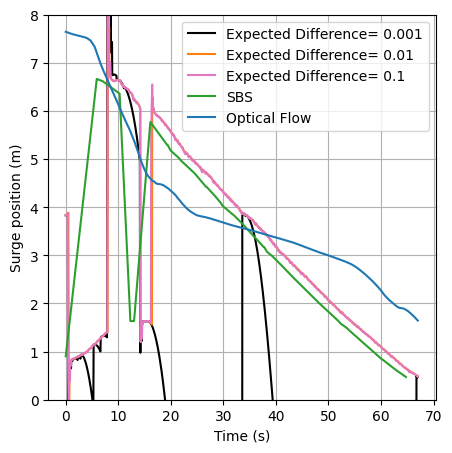

In [427]:
#Differences
color_scheme=["black","tab:orange","tab:pink"]
plt.figure(figsize=(5,5))
i=1
#plt.title("Effect of differences on KF")
for case,imu in zip(cases[:],imus[:]):
    print(case)
    df1=pd.read_csv(case)
    df2=pd.read_csv(imu)
    times=np.linspace(0,df2['Timestamp'][len(df2)-1]-df2["Timestamp"][0],len(gt_df))
    
    #if(i==0 or i==7):
    plt.plot(np.array(df2['Timestamp']-df2["Timestamp"][0]),np.array(df2["Pose_Y"]),label="Expected Difference= "+str(1/np.power(10,4-i)),color=color_scheme[i-1])
    
    
    #plt.legend()
    plt.ylim(0,8)
    #plt.show()
    i+=1
plt.plot(np.array(df1['Timestamp']-df1["Timestamp"][0]),np.array(df1["Sonar_distance_2"])/1000,label="SBS",color="tab:green")
plt.plot(times,cumulative_displacement_y,label='Optical Flow',color="tab:blue")
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Surge position (m)")
plt.grid()

In [428]:
#Persistence
cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/output_case*1205*persist*.csv"))
confidence_cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/confidence_case*persist*.csv"))
imus=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/output_IMU*1205*persist*.csv"))

/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_persist_10_.csv
/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_persist_20_.csv
/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_persist_30_.csv


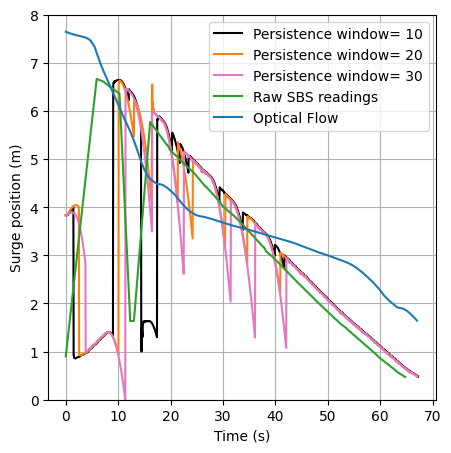

In [429]:
color_scheme=["black","tab:orange","tab:pink"]
percentages=[10,20,30]
plt.figure(figsize=(5,5))
#plt.title("Effect of persistence windows on KF")
i=0
for case,imu in zip(cases[:],imus[:]):
    print(case)
    df1=pd.read_csv(case)
    df2=pd.read_csv(imu)
    times=np.linspace(0,df2['Timestamp'][len(df2)-1]-df2["Timestamp"][0],len(gt_df))
    
    #if(i==0 or i==7):
    plt.plot(np.array(df2['Timestamp']-df2["Timestamp"][0]),np.array(df2["Pose_Y"]),label="Persistence window= "+str(percentages[i]),color=color_scheme[i])
    
    
    #plt.legend()
    plt.ylim(0,8)
    #plt.show()
    i+=1
plt.plot(np.array(df1['Timestamp']-df1["Timestamp"][0]),np.array(df1["Sonar_distance_2"])/1000,label="Raw SBS readings",color="tab:green")
plt.plot(times,cumulative_displacement_y,label='Optical Flow',color="tab:blue")
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Surge position (m)")
plt.grid()

In [430]:
#Tolerance Percentages
cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/output_case*1205*tp*.csv"))
confidence_cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/confidence_case*1205*tp*.csv"))
imus=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/output_IMU*1205*tp*.csv"))

/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_t_50_tp.csv
/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_t_75_tp.csv
/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_t_90_tp.csv


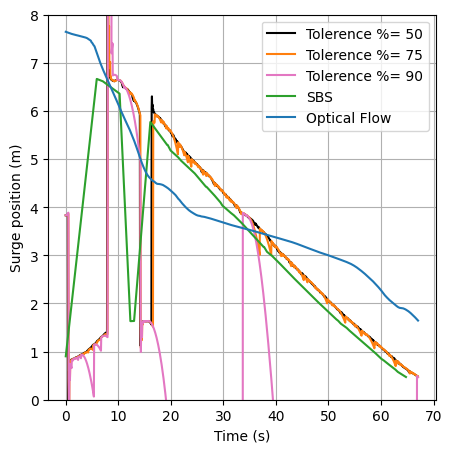

In [431]:
#Tolerance
color_scheme=["black","tab:orange","tab:pink"]
percentages=[50,75,90]
plt.figure(figsize=(5,5))
#plt.title("Effect of tolerance percentages on KF")
i=0
for case,imu in zip(cases[:],imus[:]):
    print(case)
    df1=pd.read_csv(case)
    df2=pd.read_csv(imu)
    times=np.linspace(0,df2['Timestamp'][len(df2)-1]-df2["Timestamp"][0],len(gt_df))
    
    #if(i==0 or i==7):
    plt.plot(np.array(df2['Timestamp']-df2["Timestamp"][0]),np.array(df2["Pose_Y"]),label="Tolerence %= "+str(percentages[i]),color=color_scheme[i])
    
    
    #plt.legend()
    plt.ylim(0,8)
    #plt.show()
    i+=1
plt.plot(np.array(df1['Timestamp']-df1["Timestamp"][0]),np.array(df1["Sonar_distance_2"])/1000,label="SBS",color="tab:green")
plt.plot(times,cumulative_displacement_y,label='Optical Flow',color="tab:blue")
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Surge position (m)")
plt.grid()

In [432]:
#R
cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/output_case*1205*R*.csv"))
confidence_cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/confidence_case*1205*R*.csv"))
imus=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/output_IMU*1205*R*.csv"))

/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_R_0.001_.csv
/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_R_0.01_.csv
/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_R_0.1_.csv


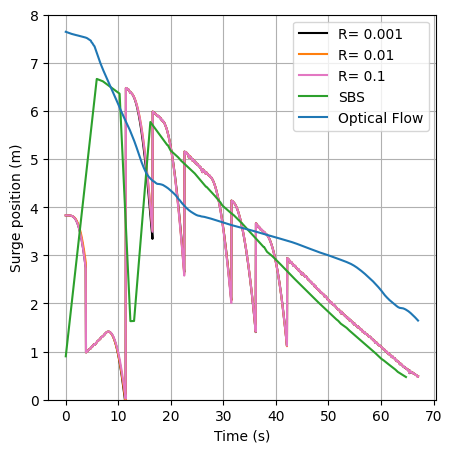

In [433]:
#R values
color_scheme=["black","tab:orange","tab:pink"]
plt.figure(figsize=(5,5))
percentages=[0.001,0.01,0.1]
#plt.title("Effect of Q on KF")
i=0
for case,imu in zip(cases[:],imus[:]):
    print(case)
    df1=pd.read_csv(case)
    df2=pd.read_csv(imu)
    times=np.linspace(0,df2['Timestamp'][len(df2)-1]-df2["Timestamp"][0],len(gt_df))
    
    #if(i==0 or i==7):
    plt.plot(np.array(df2['Timestamp']-df2["Timestamp"][0]),np.array(df2["Pose_Y"]),label="R= "+str(percentages[i]),color=color_scheme[i])
    
    
    #plt.legend()
    plt.ylim(0,8)
    #plt.show()
    i+=1
plt.plot(np.array(df1['Timestamp']-df1["Timestamp"][0]),np.array(df1["Sonar_distance_2"])/1000,label="SBS",color="tab:green")
plt.plot(times,cumulative_displacement_y,label='Optical Flow',color="tab:blue")
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Surge position (m)")
plt.grid()

In [434]:
#Q
cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/output_case*1205*Q*.csv"))
confidence_cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/confidence_case*1205*Q*.csv"))
imus=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/output_IMU*1205*Q*.csv"))

/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_Q_0.001_.csv
/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_Q_0.01_.csv
/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_Q_0.1_.csv


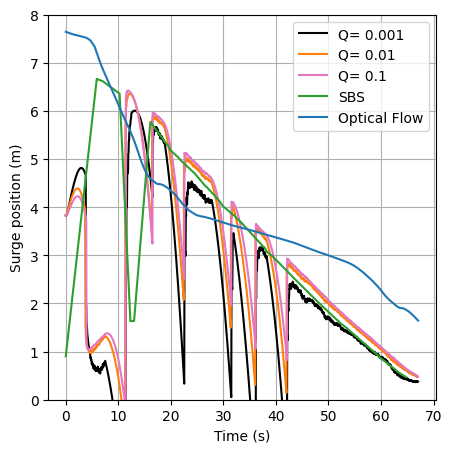

In [435]:
#Q values
color_scheme=["black","tab:orange","tab:pink"]
plt.figure(figsize=(5,5))
percentages=[0.001,0.01,0.1]
#plt.title("Effect of Q on KF")
i=0
for case,imu in zip(cases[:],imus[:]):
    print(case)
    df1=pd.read_csv(case)
    df2=pd.read_csv(imu)
    times=np.linspace(0,df2['Timestamp'][len(df2)-1]-df2["Timestamp"][0],len(gt_df))
    
    #if(i==0 or i==7):
    plt.plot(np.array(df2['Timestamp']-df2["Timestamp"][0]),np.array(df2["Pose_Y"]),label="Q= "+str(percentages[i]),color=color_scheme[i])
    
    
    #plt.legend()
    plt.ylim(0,8)
    #plt.show()
    i+=1
plt.plot(np.array(df1['Timestamp']-df1["Timestamp"][0]),np.array(df1["Sonar_distance_2"])/1000,label="SBS",color="tab:green")
plt.plot(times,cumulative_displacement_y,label='Optical Flow',color="tab:blue")
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Surge position (m)")
plt.grid()